# CE543: Homework 3
Brandon Auyeung

In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import numpy as np
import scipy.integrate as intr
import scipy.stats as stats
from sympy import Symbol
import sympy as sp
import great_tables as gt

## Problem 1

(a) For Gilroy 1, use the attenuation relation to compute ARS corresponding to the median, median plus one standard deviation, and median minus one standard deviation motions. Plot these three ARS curves along with the ARS for the recorded motion (using the geometric mean values from the NGA flatfile). How does the ARS for the recorded motion compare to that predicted by the attenuation relation – unusually high or low, etc.?

AS97 follows this:
$$ ln(S_a [G]) = f_1(M, r_{rup}) + Ff_3(M) + HWf_4(M,r_{rup}) + Sf_5(PGA_{rock}) + \epsilon \sigma $$

In [2]:
# collect data that i already filtered out (contains Coyote Lake, Morgan Hills, and Loma Prieta)
filtered_EQ_data = pd.read_excel("hw3Updated_NGA_West2_Flatfile_RotD50_d050_public_version.xlsx", sheet_name="filtered")
filtered_EQ_data

,Record Sequence Number,EQID,Earthquake Name,YEAR,MODY,HRMN,Station Name,Station Sequence Number,Station ID No.,Earthquake Magnitude,...,Instrument Nat. Freq.,Instrument Damping,Instrument Type,Quality_Flag,Spectra Quality Flag,Late S-trigger,Late P-trigger,Idirectivity,Tp,Ry 2
0,146,48,Coyote Lake,1979,806,1705,Gilroy Array #1,424,47379,5.74,...,-999,-999,-999,-999,0,-999,?,0,-999.000,-5.586326
1,147,48,Coyote Lake,1979,806,1705,Gilroy Array #2,425,47380,5.74,...,-999,-999,-999,-999,0,-999,?,1,1.463,-5.251018
2,455,90,Morgan Hill,1984,424,2115,Gilroy Array #1,424,47379,6.19,...,-999,-999,-999,-999,0,-999,?,0,-999.000,24.207436
3,456,90,Morgan Hill,1984,424,2115,Gilroy Array #2,425,47380,6.19,...,-999,-999,-999,-999,0,-999,?,0,-999.000,24.109490
4,765,118,Loma Prieta,1989,1018,5,Gilroy Array #1,424,47379,6.93,...,-999,-999,-999,-999,0,-999,?,0,-999.000,26.408614
5,766,118,Loma Prieta,1989,1018,5,Gilroy Array #2,425,47380,6.93,...,-999,-999,-999,-999,0,-999,?,1,1.729,26.907282


In [3]:
# collect relavent information
loma_rock_data = filtered_EQ_data.iloc[4]
loma_rock_data

Record Sequence Number            765
EQID                              118
Earthquake Name           Loma Prieta
YEAR                             1989
MODY                             1018
                             ...     
Late S-trigger                   -999
Late P-trigger                      ?
Idirectivity                        0
Tp                             -999.0
Ry 2                        26.408614
Name: 4, Length: 274, dtype: object

In [4]:
# EQ parameters for model
loma_M = loma_rock_data["Earthquake Magnitude"]
loma_r_rup = loma_rock_data["ClstD (km)"]
loma_site = 0 # 0 for rock site, 1 for soil site (AS97)
loma_mechanism = 0.5 # mechanism based on rake is 3. therefore, reverse-oblique, which is 0.5 (AS97)
loma_HW = 0 # "FW/HW Indicator" is "nu", which is "neutral". thereforem, HW = 0 (AS97)
n = 2 # vertical = 3, horizontal = 2 (AS97)

print(f"Earthquake Magnitude: {loma_M}")
print(f"r_rupt (km): {loma_r_rup}")
print(f"site: {loma_site}")
print(f"mechanism: {loma_mechanism}")
print(f"HW: {loma_HW}")
print(f"n: {n}")

Earthquake Magnitude: 6.93
r_rupt (km): 9.64
site: 0
mechanism: 0.5
HW: 0
n: 2


In [5]:
# constants for AS97 as a function of structual period
as97_const = pd.read_excel("abrahamson_silva_coefficients.xls", sheet_name="const")
as97_const

,period,c4,a1,a2,a3,a4,a5,a6,a9,a10,a11,a12,a13,c1,c5,n,b5,b6
0,0.010,5.6000,1.6400,0.512,-1.1450,-0.144,0.6100,0.2600,0.3700,-0.4170,-0.2300,0.0000,0.17,6.4,0.03,2,0.700,0.135
1,0.030,5.6000,1.6900,0.512,-1.1450,-0.144,0.6100,0.2600,0.3700,-0.4700,-0.2300,0.0143,0.17,6.4,0.03,2,0.700,0.135
2,0.050,5.6000,1.8700,0.512,-1.1450,-0.144,0.6100,0.2600,0.3700,-0.6200,-0.2668,0.0280,0.17,6.4,0.03,2,0.713,0.135
3,0.075,5.5845,2.0370,0.512,-1.1450,-0.144,0.6100,0.2600,0.3700,-0.6281,-0.2800,0.0300,0.17,6.4,0.03,2,0.728,0.135
4,0.100,5.5000,2.1600,0.512,-1.1450,-0.144,0.6100,0.2600,0.3700,-0.5977,-0.2800,0.0280,0.17,6.4,0.03,2,0.739,0.135
5,0.120,5.3948,2.2772,0.512,-1.1450,-0.144,0.6100,0.2600,0.3700,-0.5914,-0.2800,0.0180,0.17,6.4,0.03,2,0.746,0.135
6,0.150,5.2660,2.4065,0.512,-1.1450,-0.144,0.6100,0.2600,0.3700,-0.5766,-0.2800,0.0050,0.17,6.4,0.03,2,0.754,0.135
7,0.170,5.1938,2.4300,0.512,-1.1350,-0.144,0.6100,0.2600,0.3700,-0.5218,-0.2647,-0.0040,0.17,6.4,0.03,2,0.759,0.135
8,0.200,5.1000,2.4057,0.512,-1.1150,-0.144,0.6100,0.2600,0.3700,-0.4450,-0.2448,-0.0138,0.17,6.4,0.03,2,0.765,0.135
9,0.240,4.9652,2.2925,0.512,-1.0790,-0.144,0.6100,0.2320,0.3700,-0.3498,-0.2225,-0.0238,0.17,6.4,0.03,2,0.772,0.135


### AS97

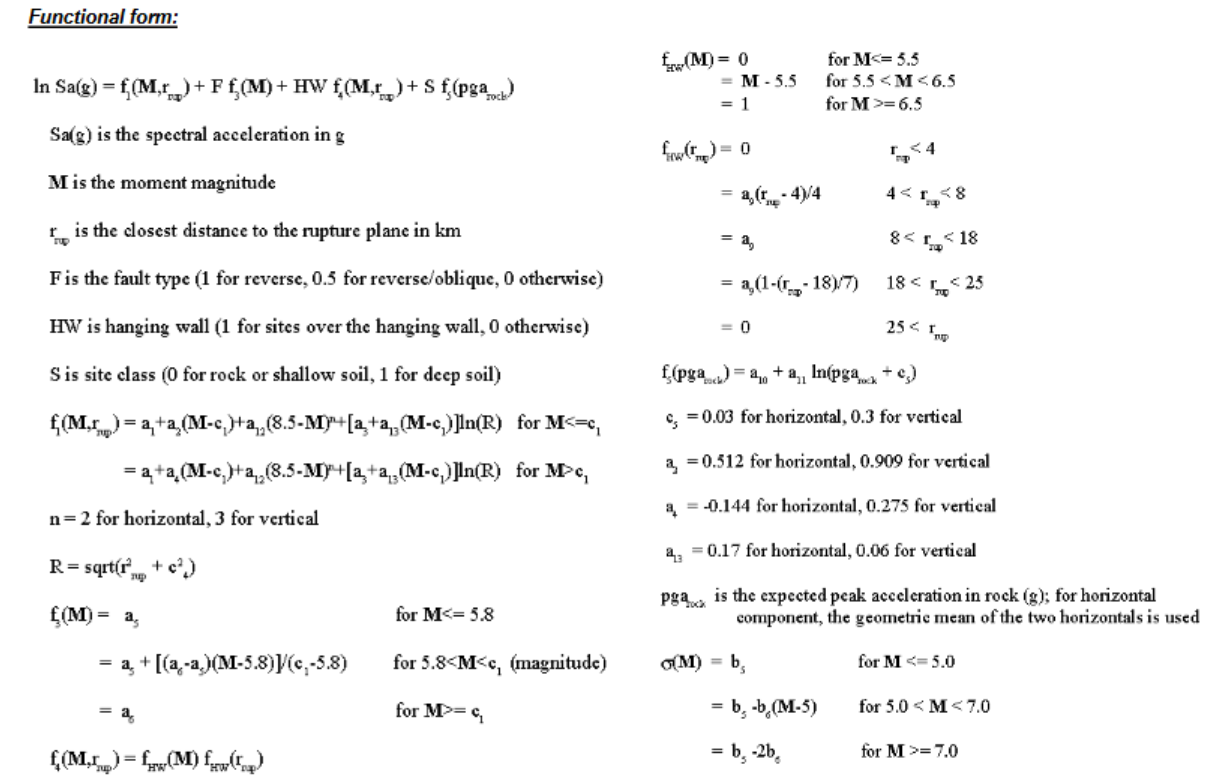

In [6]:
# collect R values
R = np.zeros(len(as97_const["period"])) # initialize R
for i in range(len(as97_const["period"])): # for each period
    R[i] = (loma_r_rup**2 + as97_const["c4"][i]**2)**0.5

# collect f1 values
f1_rock = np.zeros(len(as97_const["period"])) # initialize f1
for i in range(len(as97_const["period"])): # for each period
    if loma_M <= as97_const["c1"][i]: # if M <= c1...
        f1_rock[i] = as97_const["a1"][i] + (as97_const["a2"][i] * (loma_M - as97_const["c1"][i])) + (as97_const["a12"][i]*(8.5 - loma_M)**n) + \
            (as97_const["a3"][i] +(as97_const["a13"][i] * (loma_M-as97_const["c1"][i])))*np.log(R[i]) # collect f1 value
    else: # if M > c1...
        f1_rock[i] = as97_const["a1"][i] + (as97_const["a4"][i] * (loma_M - as97_const["c1"][i])) + (as97_const["a12"][i]*(8.5 - loma_M)**n) + \
            (as97_const["a3"][i] +(as97_const["a13"][i] * (loma_M-as97_const["c1"][i])))*np.log(R[i]) # collect f1 value
            
# collect f3 values
f3_rock = np.zeros(len(as97_const["period"])) # initialize f3
for i in range(len(as97_const["period"])): # for each period
    if loma_M <= 5.8: # if M <= 5.8...
        f3_rock[i] = as97_const["a5"][i] # collect f3 value
    elif 5.8 < loma_M  <= as97_const["c1"][i]: # if M > 5.8 and M <= 6.2...
        f3_rock[i] = as97_const["a5"][i] + (((as97_const["a6"][i] - as97_const["a5"][i])*(loma_M-5.8))/(as97_const["c1"][i]-5.8)) # collect f3 value
    else: # if M > 6.2...
        f3_rock[i] = as97_const["a6"][i] # collect f3 value

# in order to get f4, we need fHW_hw and fHW_r 
fHW_hw_rock = np.zeros(len(as97_const["period"])) # initialize fHW_hw
for i in range(len(as97_const["period"])): # for each period
    if loma_M <= 5.5: # if if M <= 5.5
        fHW_hw_rock[i] = 0 # collect fHW_hw value
    elif 5.5 < loma_M  <= 6.5: # if 5.5 < M <= 6.5...
        fHW_hw_rock[i] = loma_M - 5.5 # collect fHW_hw value
    else: # if M > 6.5
        fHW_hw_rock[i] = 1 # collect fHW_hw value

fHW_r_rock = np.zeros(len(as97_const["period"])) # initialize fHW_r
for i in range(len(as97_const["period"])): # for each period
    if loma_r_rup < 4: 
        fHW_r_rock[i] = 0 # collect fHW_r value
    elif 4 <= loma_r_rup < 8: 
        fHW_r_rock[i] = (as97_const["a9"][i] * (loma_r_rup - 4))/4 # collect fHW_r value
    elif 8 <= loma_r_rup < 18: 
        fHW_r_rock[i] = as97_const["a9"][i] # collect fHW_r value
    elif 18 <= loma_r_rup < 25: 
        fHW_r_rock[i] = as97_const["a9"][i] * (((1-(loma_r_rup - 18))/7))  # collect fHW_r value
    else:
        fHW_r_rock[i] = 0 # collect fHW_r value

# finally we can get f4...
f4_rock = fHW_hw_rock * fHW_r_rock

# collect f5 values. must ignore f5 first, then run again
f5_rock = np.zeros(len(as97_const["period"])) # initialize f5, we will collect this later

In [7]:

# factors_rock = pd.DataFrame({"f1": f1_rock, "f3": f3_rock, "f4": f4_rock})
factors_rock = pd.DataFrame({"f1": f1_rock, "f3": f3_rock, "f4": f4_rock, "f5": f5_rock})
factors_rock

,f1,f3,f4,f5
0,-0.980008,0.2600,0.3700,0.0
1,-0.894760,0.2600,0.3700,0.0
2,-0.680991,0.2600,0.3700,0.0
3,-0.508325,0.2600,0.3700,0.0
4,-0.386259,0.2600,0.3700,0.0
5,-0.288777,0.2600,0.3700,0.0
6,-0.185553,0.2600,0.3700,0.0
7,-0.156992,0.2600,0.3700,0.0
8,-0.153437,0.2600,0.3700,0.0
9,-0.199598,0.2320,0.3700,0.0


In [8]:
# combine factors with flags to get ln(S_a) and by extension, S_a
loma_pga = 0 # we will collect this later
print(loma_site)
lnSa_rock_median = np.zeros(len(as97_const["period"])) # initialize lnSa
for i in range(len(as97_const["period"])): # for each period
    if i == 0:
        print(f"f1: {f1_rock[i]}")
        print(f"f3: {loma_mechanism * f3_rock[i]}")
        print(f"f4: {loma_HW * f4_rock[i]}")
        # print(f"f5: {loma_site*f5_rock[i]}")
        loma_pga = np.exp(f1_rock[i] + loma_mechanism * f3_rock[i] + loma_HW * f4_rock[i])  # collect lnSa value
        print(f"PGA_rock: {loma_pga}")
        f5_rock[i] = as97_const["a10"][i] + as97_const["a11"][i] * np.log(loma_pga + as97_const["c5"][i]) # collect f5 value
        lnSa_rock_median[i] = f1_rock[i] + loma_mechanism * f3_rock[i] + loma_HW * f4_rock[i] + loma_site*f5_rock[i]  # collect lnSa value
        print(f"ln(S_a [g]): {lnSa_rock_median[i]}")
    
    else:
        for i in range(len(as97_const["period"])): # for each period
            f5_rock[i] = as97_const["a10"][i] + as97_const["a11"][i] * np.log(loma_pga + as97_const["c5"][i]) # collect f5 value
            lnSa_rock_median[i] = f1_rock[i] + loma_mechanism * f3_rock[i] + loma_HW * f4_rock[i] + loma_site*f5_rock[i]  # collect lnSa value
        
print(f"f5_rock: {f5_rock}")
print(f"Structural Periods [sec]: {np.asarray(as97_const['period'], 'float')}")
print(f"ln(S_a [g]): {lnSa_rock_median}") # median case of lnSa
Sa_rock_mean = np.exp(lnSa_rock_median)

print(f"S_a [g]: {Sa_rock_mean}") # mean case of Sa


0
f1: -0.9800079264978743
f3: 0.13
f4: 0.0
PGA_rock: 0.4274115440586042
ln(S_a [g]): -0.8500079264978743
f5_rock: [-0.2371005  -0.2901005  -0.41131657 -0.40909191 -0.37869191 -0.37239191
 -0.35759191 -0.31475914 -0.25352435 -0.17576678 -0.06672007  0.06014748
  0.17964278  0.35926502  0.4231      0.56861313  0.57871313  0.59871313
  0.60871313  0.63281313]
Structural Periods [sec]: [0.01  0.03  0.05  0.075 0.1   0.12  0.15  0.17  0.2   0.24  0.3   0.4
 0.5   0.75  1.    1.5   2.    3.    4.    5.   ]
ln(S_a [g]): [-0.85000793 -0.76475986 -0.55099073 -0.37832472 -0.25625904 -0.15877737
 -0.0555526  -0.02699158 -0.02343729 -0.08359841 -0.19791234 -0.39093331
 -0.58821086 -0.96178345 -1.24016272 -1.72548676 -2.09614824 -2.74770398
 -3.26639668 -3.64421574]
S_a [g]: [0.42741154 0.46544569 0.57637849 0.68500803 0.77394146 0.85318628
 0.94596226 0.97336944 0.97683523 0.91980057 0.82044177 0.67642526
 0.55531994 0.38221062 0.28933713 0.17808634 0.12292901 0.06407481
 0.03814362 0.0261419 ]


In [9]:
factors_rock["f5"] = f5_rock

factors_rock

,f1,f3,f4,f5
0,-0.980008,0.2600,0.3700,-0.237100
1,-0.894760,0.2600,0.3700,-0.290100
2,-0.680991,0.2600,0.3700,-0.411317
3,-0.508325,0.2600,0.3700,-0.409092
4,-0.386259,0.2600,0.3700,-0.378692
5,-0.288777,0.2600,0.3700,-0.372392
6,-0.185553,0.2600,0.3700,-0.357592
7,-0.156992,0.2600,0.3700,-0.314759
8,-0.153437,0.2600,0.3700,-0.253524
9,-0.199598,0.2320,0.3700,-0.175767


In [10]:
# determine +/- 1σ 
sigma = np.zeros(len(as97_const['period']))
for i in range(len(as97_const['period'])):
    if loma_M <= 5:
        sigma[i] = as97_const["b5"][i]
    elif 5 < loma_M <= 7:
        sigma[i] = as97_const['b5'][i] - (as97_const['b6'][i] *( loma_M -5))
    else:
        sigma[i] = as97_const['b5'][i] - 2*as97_const['b6'][i]
# print(sigma)
factors_rock['sigma'] = sigma

lnSa_rock_high = np.zeros(len(as97_const['period']))
lnSa_rock_low = np.zeros(len(as97_const['period']))

for i in range(len(as97_const["period"])): # for each period
    lnSa_rock_high[i] = f1_rock[i] + loma_mechanism * f3_rock[i] + loma_HW * f4_rock[i] + loma_site*f5_rock[i] + sigma[i] # collect lnSa value
    lnSa_rock_low[i] = f1_rock[i] + loma_mechanism * f3_rock[i] + loma_HW * f4_rock[i] + loma_site*f5_rock[i] - sigma[i] # collect lnSa value

Sa_rock_high = np.exp(lnSa_rock_high)
Sa_rock_low = np.exp(lnSa_rock_low)

# print(Sa_rock_high)
print(lnSa_rock_median)
print(Sa_rock_mean)
# print(Sa_rock_low)

[-0.85000793 -0.76475986 -0.55099073 -0.37832472 -0.25625904 -0.15877737
 -0.0555526  -0.02699158 -0.02343729 -0.08359841 -0.19791234 -0.39093331
 -0.58821086 -0.96178345 -1.24016272 -1.72548676 -2.09614824 -2.74770398
 -3.26639668 -3.64421574]
[0.42741154 0.46544569 0.57637849 0.68500803 0.77394146 0.85318628
 0.94596226 0.97336944 0.97683523 0.91980057 0.82044177 0.67642526
 0.55531994 0.38221062 0.28933713 0.17808634 0.12292901 0.06407481
 0.03814362 0.0261419 ]


In [11]:
print((lnSa_rock_high[0]))
print((lnSa_rock_median[0]))
print((lnSa_rock_low[0]))
factors_rock

-0.4105579264978743
-0.8500079264978743
-1.2894579264978743


,f1,f3,f4,f5,sigma
0,-0.980008,0.2600,0.3700,-0.237100,0.43945
1,-0.894760,0.2600,0.3700,-0.290100,0.43945
2,-0.680991,0.2600,0.3700,-0.411317,0.45245
3,-0.508325,0.2600,0.3700,-0.409092,0.46745
4,-0.386259,0.2600,0.3700,-0.378692,0.47845
5,-0.288777,0.2600,0.3700,-0.372392,0.48545
6,-0.185553,0.2600,0.3700,-0.357592,0.49345
7,-0.156992,0.2600,0.3700,-0.314759,0.49845
8,-0.153437,0.2600,0.3700,-0.253524,0.50445
9,-0.199598,0.2320,0.3700,-0.175767,0.51145


In [12]:
amp_data = pd.DataFrame(filtered_EQ_data, columns=["Earthquake Name", "Station Name"])
spectra_data = amp_data.join(filtered_EQ_data.iloc[:, 134:244]) # add the EQ aned Station data with the spectra data
# print(spectra_data.columns[2:] )
spectra_col_names = ["EQ", "Station"]
for index, col in enumerate(spectra_data.columns[2:]): # for each column that is part of the spectra data
    spectra_col_names.append(spectra_data.columns[2+index].removeprefix("T").removesuffix("S")) # remove the T and S

spectra_data.columns = spectra_col_names

print(spectra_data)

            EQ          Station     0.010     0.020     0.022     0.025  \
0  Coyote Lake  Gilroy Array #1  0.107015  0.112627  0.112819  0.114576   
1  Coyote Lake  Gilroy Array #2  0.247895  0.258362  0.263062  0.264814   
2  Morgan Hill  Gilroy Array #1  0.077343  0.084820  0.085522  0.091446   
3  Morgan Hill  Gilroy Array #2  0.173973  0.176858  0.177787  0.177201   
4  Loma Prieta  Gilroy Array #1  0.437089  0.477591  0.479794  0.496725   
5  Loma Prieta  Gilroy Array #2  0.356921  0.358833  0.359434  0.359078   

      0.029     0.030     0.032     0.035  ...     8.000     8.500     9.000  \
0  0.124465  0.130651  0.145066  0.153106  ...  0.001397  0.001198  0.001101   
1  0.263912  0.262629  0.258442  0.262997  ...  0.003176  0.002784  0.002460   
2  0.089151  0.089719  0.097692  0.118499  ...  0.001085  0.000868  0.000732   
3  0.178613  0.180773  0.183319  0.188927  ...  0.001849  0.001366  0.001070   
4  0.526296  0.534072  0.534103  0.543660  ...  0.009300  0.008176  0.0072

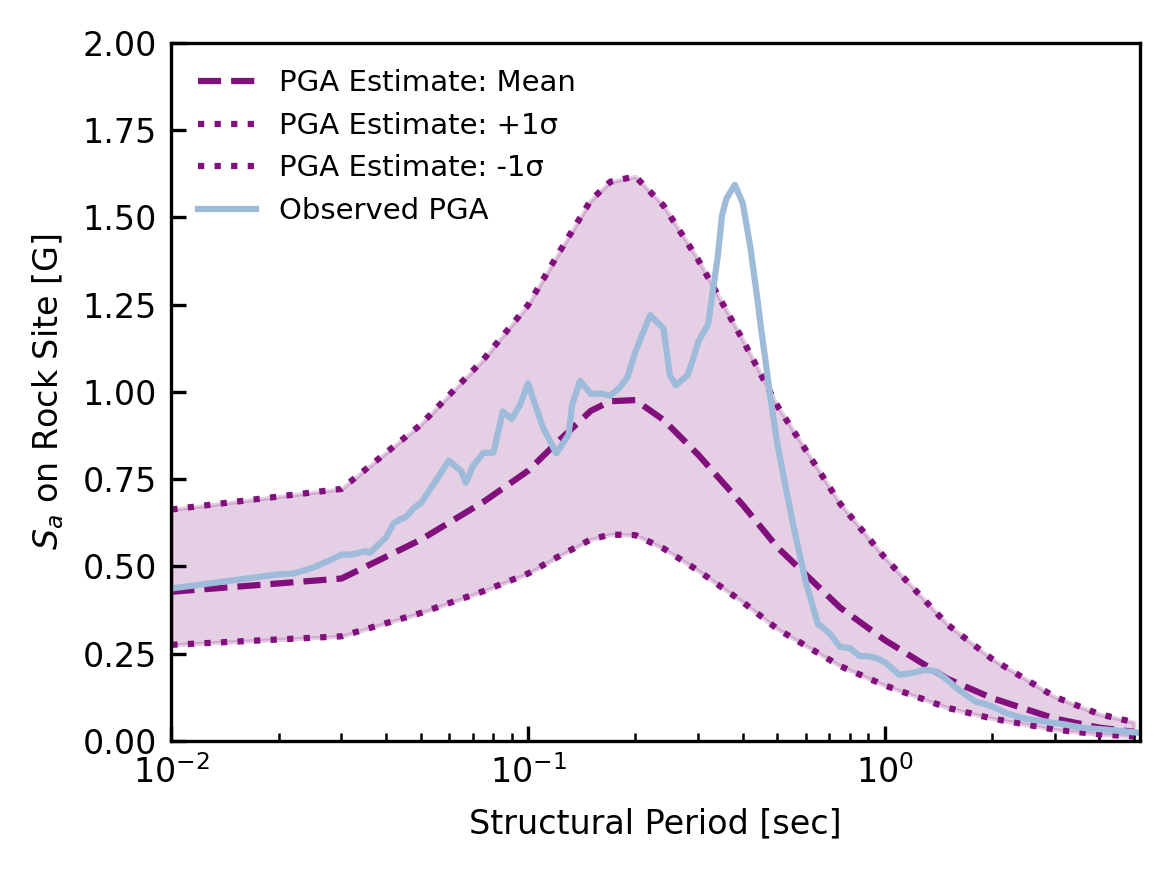

In [13]:
fig, ax = subplots(figsize=(4,3), tight_layout=True, dpi=300)
ax.semilogx(np.asarray(as97_const["period"], "float"), Sa_rock_mean, color = "#810f7c", label="PGA Estimate: Mean", linestyle ="--")
ax.semilogx(np.asarray(as97_const["period"], "float"), Sa_rock_high, color = "#810f7c", label="PGA Estimate: +1σ", linestyle = ":")
ax.semilogx(np.asarray(as97_const["period"], "float"), Sa_rock_low, color = "#810f7c", label="PGA Estimate: -1σ", linestyle = ":")
ax.fill_between(np.asarray(as97_const["period"], "float"), Sa_rock_low, Sa_rock_high, color = "#810f7c", alpha = 0.2)

loma_rock_spectra = spectra_data.iloc[4, 2:] # determine the site ratio for the Loma Prieta EQ
ax.semilogx(np.asarray(loma_rock_spectra.index.values, "float"), loma_rock_spectra, color = "#9ebcda", label="Observed PGA")


plt.legend(loc="best", fontsize=7, frameon=False)

ax.set_xlabel("Structural Period [sec]", fontsize = 8)
ax.set_xbound(0.01, 5.2)
ax.set_ylabel("$S_a$ on Rock Site [G]", fontsize =8)
ax.set_ybound(0, 2)
ax.tick_params(which="both", direction = "in", labelsize = 8)

(b) For Gilroy 2, prepare the same plot as requested in (a). How does the ARS for the recorded motion compare to that predicted by the attenuation relation?

Just modify the above code...

In [14]:
# collect relavent information
loma_soil_data = filtered_EQ_data.iloc[5]
loma_soil_data

Record Sequence Number            766
EQID                              118
Earthquake Name           Loma Prieta
YEAR                             1989
MODY                             1018
                             ...     
Late S-trigger                   -999
Late P-trigger                      ?
Idirectivity                        1
Tp                              1.729
Ry 2                        26.907282
Name: 5, Length: 274, dtype: object

In [15]:
# EQ parameters for model
loma_M = loma_soil_data["Earthquake Magnitude"]
loma_r_rup = loma_soil_data["ClstD (km)"]
loma_site = 1 # 0 for rock site, 1 for soil site (AS97)
loma_mechanism = 0.5 # mechanism based on rake is 3. therefore, reverse-oblique, which is 0.5 (AS97)
loma_HW = 0 # "FW/HW Indicator" is "nu", which is "neutral". thereforem, HW = 0 (AS97)
n = 2 # vertical = 3, horizontal = 2 (AS97)

print(f"Earthquake Magnitude: {loma_M}")
print(f"r_rupt (km): {loma_r_rup}")
print(f"site: {loma_site}")
print(f"mechanism: {loma_mechanism}")
print(f"HW: {loma_HW}")
print(f"n: {n}")

Earthquake Magnitude: 6.93
r_rupt (km): 11.07
site: 1
mechanism: 0.5
HW: 0
n: 2


In [16]:
R = np.zeros(len(as97_const["period"])) # initialize R
for i in range(len(as97_const["period"])): # for each period
    R[i] = (loma_r_rup**2 + as97_const["c4"][i]**2)**0.5

f1_soil = np.zeros(len(as97_const["period"])) # initialize f1
for i in range(len(as97_const["period"])): # for each period
    if loma_M <= as97_const["c1"][i]: # if M <= c1...
        f1_soil[i] = as97_const["a1"][i] + (as97_const["a2"][i] * (loma_M - as97_const["c1"][i])) + (as97_const["a12"][i]*(8.5 - loma_M)**n) + \
            (as97_const["a3"][i] +(as97_const["a13"][i] * (loma_M-as97_const["c1"][i])))*np.log(R[i]) # collect f1 value
    else: # if M > c1...
        f1_soil[i] = as97_const["a1"][i] + (as97_const["a4"][i] * (loma_M - as97_const["c1"][i])) + (as97_const["a12"][i]*(8.5 - loma_M)**n) + \
            (as97_const["a3"][i] +(as97_const["a13"][i] * (loma_M-as97_const["c1"][i])))*np.log(R[i]) # collect f1 value

# collect f3 values
f3_soil = np.zeros(len(as97_const["period"])) # initialize f3
for i in range(len(as97_const["period"])): # for each period
    if loma_M <= 5.8: # if M <= 5.8...
        f3_soil[i] = as97_const["a5"][i] # collect f3 value
    elif 5.8 < loma_M  <= as97_const["c1"][i]: # if M > 5.8 and M <= 6.2...
        f3_soil[i] = as97_const["a5"][i] + (((as97_const["a6"][i] - as97_const["a5"][i])*(loma_M-5.8))/(as97_const["c1"][i]-5.8)) # collect f3 value
    else: # if M > 6.2...
        f3_soil[i] = as97_const["a6"][i] # collect f3 value

# in order to get f4, we need fHW_hw and fHW_r 
fHW_hw_soil = np.zeros(len(as97_const["period"])) # initialize fHW_hw
for i in range(len(as97_const["period"])): # for each period
    if loma_M <= 5.5: # if if M <= 5.5
        fHW_hw_soil[i] = 0 # collect fHW_hw value
    elif 5.5 < loma_M  <= 6.5: # if 5.5 < M <= 6.5...
        fHW_hw_soil[i] = loma_M - 5.5 # collect fHW_hw value
    else: # if M > 6.5
        fHW_hw_soil[i] = 1 # collect fHW_hw value

fHW_r_soil = np.zeros(len(as97_const["period"])) # initialize fHW_r
for i in range(len(as97_const["period"])): # for each period
    if loma_r_rup < 4: 
        fHW_r_soil[i] = 0 # collect fHW_r value
    elif 4 <= loma_r_rup < 8: 
        fHW_r_soil[i] = (as97_const["a9"][i] * (loma_r_rup - 4))/4 # collect fHW_r value
    elif 8 <= loma_r_rup < 18: 
        fHW_r_soil[i] = as97_const["a9"][i] # collect fHW_r value
    elif 18 <= loma_r_rup < 25: 
        fHW_r_soil[i] = as97_const["a9"][i] * (((1-(loma_r_rup - 18))/7))  # collect fHW_r value
    else:
        fHW_r_soil[i] = 0 # collect soilr value

# finally we can get f4...
f4_soil = fHW_hw_soil * fHW_r_soil

# collect f5 values
f5_soil = np.zeros(len(as97_const["period"])) # initialize f5


In [17]:
# collect all factors in AS97 for median case
factors_soil = pd.DataFrame({"f1": f1_soil, "f3": f3_soil, "f4": f4_soil, "f5": f5_soil})
factors_soil

,f1,f3,f4,f5
0,-1.092735,0.2600,0.3700,0.0
1,-1.007487,0.2600,0.3700,0.0
2,-0.793718,0.2600,0.3700,0.0
3,-0.621193,0.2600,0.3700,0.0
4,-0.499900,0.2600,0.3700,0.0
5,-0.403377,0.2600,0.3700,0.0
6,-0.301323,0.2600,0.3700,0.0
7,-0.272313,0.2600,0.3700,0.0
8,-0.267375,0.2600,0.3700,0.0
9,-0.310670,0.2320,0.3700,0.0


In [18]:
# combine factors with flags to get ln(S_a) and by extension, S_a

lnSa_soil_median = np.zeros(len(as97_const["period"])) # initialize lnSa
for i in range(len(as97_const["period"])): # for each period
    if i == 0:
        print(f"f1: {f1_soil[i]}")
        print(f"f3: {loma_mechanism * f3_soil[i]}")
        print(f"f4: {loma_HW * f4_soil[i]}")
        # print(f"f5: {loma_site*f5_rock[i]}")
        loma_pga = np.exp(f1_soil[i] + loma_mechanism * f3_soil[i] + loma_HW * f4_soil[i])  # collect lnSa value
        print(f"PGA_rock: {loma_pga}")
        f5_soil[i] = as97_const["a10"][i] + as97_const["a11"][i] * np.log(loma_pga + as97_const["c5"][i]) # collect f5 value
        lnSa_soil_median[i] = f1_soil[i] + loma_mechanism * f3_soil[i] + loma_HW * f4_soil[i] + loma_site*f5_soil[i]  # collect lnSa value
        print(f"ln(S_a [g]): {lnSa_soil_median[i]}")
    else:
        for i in range(len(as97_const["period"])): # for each period
            f5_soil[i] = as97_const["a10"][i] + as97_const["a11"][i] * np.log(loma_pga + as97_const["c5"][i]) # collect f5 value
            lnSa_soil_median[i] = f1_soil[i] + loma_mechanism * f3_soil[i] + loma_HW * f4_soil[i] + loma_site*f5_soil[i]  # collect lnSa value
        

print(f"Structural Periods [sec]: {np.asarray(as97_const['period'], 'float')}")
print(f"ln(S_a [g]): {lnSa_soil_median}") # median case of lnSa
Sa_soil_mean = np.exp(lnSa_soil_median)

print(f"S_a [g]: {Sa_soil_mean}") # mean case of Sa


f1: -1.0927348320310808
f3: 0.13
f4: 0.0
PGA_rock: 0.3818471688282185
ln(S_a [g]): -1.1757011540146678
Structural Periods [sec]: [0.01  0.03  0.05  0.075 0.1   0.12  0.15  0.17  0.2   0.24  0.3   0.4
 0.5   0.75  1.    1.5   2.    3.    4.    5.   ]
ln(S_a [g]): [-1.17570115 -1.14345308 -1.04703857 -0.87090455 -0.71921092 -0.61638854
 -0.49953467 -0.42929694 -0.365212   -0.34708953 -0.35160058 -0.41821148
 -0.49738917 -0.6934803  -0.90875958 -1.24541652 -1.60038694 -2.23194268
 -2.74063538 -3.09435444]
S_a [g]: [0.30860253 0.31871656 0.3509756  0.41857276 0.48713649 0.53989071
 0.60681296 0.6509666  0.6940495  0.70674205 0.70356108 0.65822301
 0.60811628 0.49983347 0.40302383 0.287821   0.20181841 0.10731974
 0.06452933 0.04530425]


In [19]:
# determine +/- 1σ 

lnSa_soil_high = np.zeros(len(as97_const['period']))
lnSa_soil_low = np.zeros(len(as97_const['period']))

for i in range(len(as97_const["period"])): # for each period
    lnSa_soil_high[i] = f1_soil[i] + loma_mechanism * f3_soil[i] + loma_HW * f4_soil[i] + loma_site*f5_soil[i] + sigma[i] # collect lnSa value
    lnSa_soil_low[i] = f1_soil[i] + loma_mechanism * f3_soil[i] + loma_HW * f4_soil[i] + loma_site*f5_soil[i] - sigma[i] # collect lnSa value

Sa_soil_high = np.exp(lnSa_soil_high)
Sa_soil_low = np.exp(lnSa_soil_low)

print(lnSa_soil_high)
print(lnSa_soil_median)
print(lnSa_soil_low)

print(Sa_soil_high)
print(Sa_soil_mean)
print(Sa_soil_low)

[-0.73625115 -0.70400308 -0.59458857 -0.40345455 -0.24076092 -0.13093854
 -0.00608467  0.06915306  0.139238    0.16436047  0.16784942  0.11223852
  0.05071083 -0.1168703  -0.31149958 -0.61771652 -0.95203694 -1.55315268
 -2.04119538 -2.37726444]
[-1.17570115 -1.14345308 -1.04703857 -0.87090455 -0.71921092 -0.61638854
 -0.49953467 -0.42929694 -0.365212   -0.34708953 -0.35160058 -0.41821148
 -0.49738917 -0.6934803  -0.90875958 -1.24541652 -1.60038694 -2.23194268
 -2.74063538 -3.09435444]
[-1.61515115 -1.58290308 -1.49948857 -1.33835455 -1.19766092 -1.10183854
 -0.99298467 -0.92774694 -0.869662   -0.85853953 -0.87105058 -0.94866148
 -1.04548917 -1.2700903  -1.50601958 -1.87311652 -2.24873694 -2.91073268
 -3.44007538 -3.81144444]
[0.4789059  0.4946014  0.55178954 0.66800839 0.78602953 0.87727169
 0.9939338  1.07160022 1.14939763 1.17863911 1.1827585  1.11877968
 1.05201864 0.88970058 0.73234792 0.53917423 0.38595406 0.21157988
 0.12987337 0.0928041 ]
[0.30860253 0.31871656 0.3509756  0.4185

In [20]:
factors_soil["f5"] = f5_soil
factors_soil

,f1,f3,f4,f5
0,-1.092735,0.2600,0.3700,-0.212966
1,-1.007487,0.2600,0.3700,-0.265966
2,-0.793718,0.2600,0.3700,-0.383321
3,-0.621193,0.2600,0.3700,-0.379711
4,-0.499900,0.2600,0.3700,-0.349311
5,-0.403377,0.2600,0.3700,-0.343011
6,-0.301323,0.2600,0.3700,-0.328211
7,-0.272313,0.2600,0.3700,-0.286984
8,-0.267375,0.2600,0.3700,-0.227837
9,-0.310670,0.2320,0.3700,-0.152420


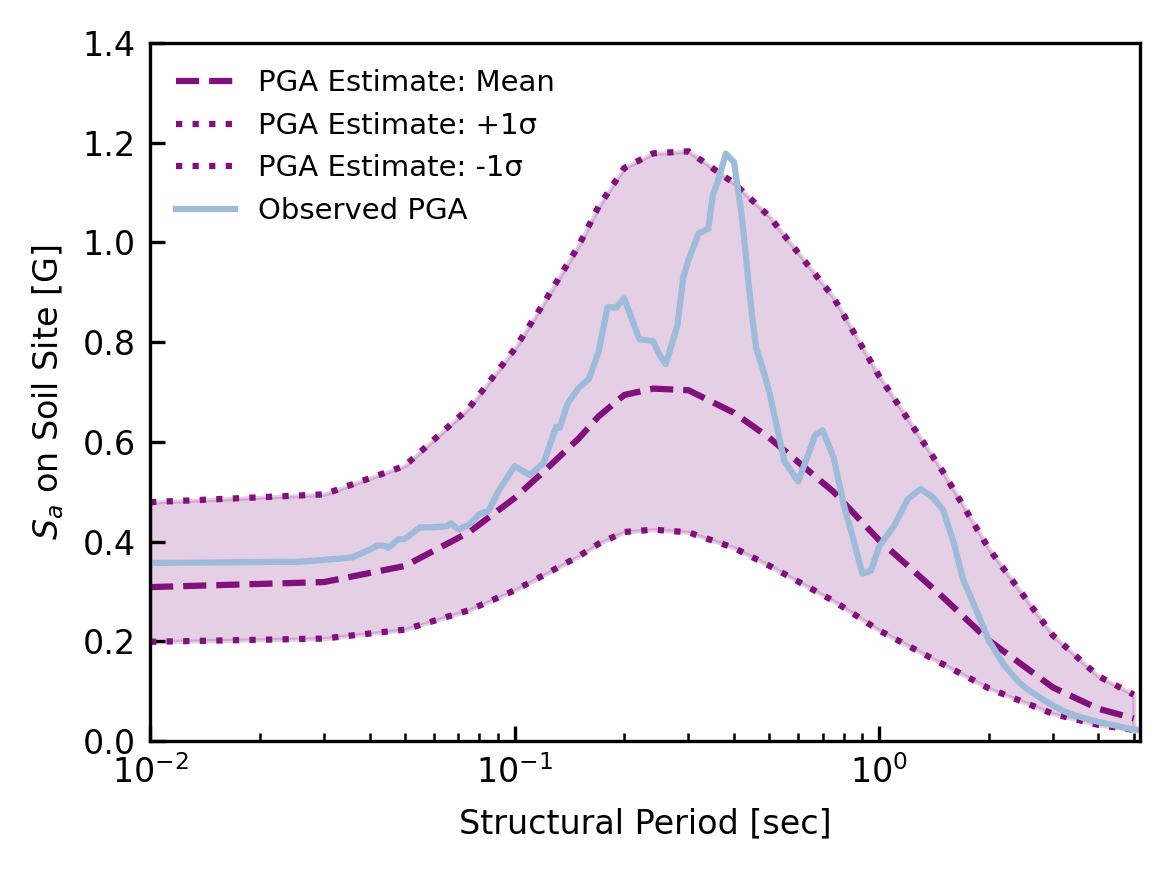

In [21]:
fig, ax = subplots(figsize=(4,3), tight_layout=True, dpi=300)
ax.semilogx(np.asarray(as97_const["period"], "float"), Sa_soil_mean, color = "#810f7c", label="PGA Estimate: Mean", linestyle ="--")
ax.semilogx(np.asarray(as97_const["period"], "float"), Sa_soil_high, color = "#810f7c", label="PGA Estimate: +1σ", linestyle = ":")
ax.semilogx(np.asarray(as97_const["period"], "float"), Sa_soil_low, color = "#810f7c", label="PGA Estimate: -1σ", linestyle = ":")
ax.fill_between(np.asarray(as97_const["period"], "float"), Sa_soil_low, Sa_soil_high, color = "#810f7c", alpha = 0.2)

loma_soil_spectra = spectra_data.iloc[5, 2:] # determine the site ratio for the Loma Prieta EQ
ax.semilogx(np.asarray(loma_soil_spectra.index.values, "float"), loma_soil_spectra, color = "#9ebcda", label="Observed PGA")


plt.legend(loc="best", fontsize=7, frameon=False)

ax.set_xlabel("Structural Period [sec]", fontsize = 8)
ax.set_xbound(0.01, 5.2)
ax.set_ylabel("$S_a$ on Soil Site [G]", fontsize =8)
ax.set_ybound(0, 1.4)
ax.tick_params(which="both", direction = "in", labelsize = 8)

In [22]:
sigma

array([0.43945, 0.43945, 0.45245, 0.46745, 0.47845, 0.48545, 0.49345,
       0.49845, 0.50445, 0.51145, 0.51945, 0.53045, 0.5481 , 0.57661,
       0.59726, 0.6277 , 0.64835, 0.67879, 0.69944, 0.71709])

(c) Compute the ratio of the ARS values on soil at Gilroy 2 to those on rock at Gilroy 1 for both the recorded motions and the attenuation relation (use the median values). Plot these ratios versus period. How do the ARS ratios for the recorded motions compare to the average trend predicted by the attenuation relation?

In [23]:
SR_obs = loma_soil_spectra/loma_rock_spectra
SR_model = Sa_soil_mean/Sa_rock_mean

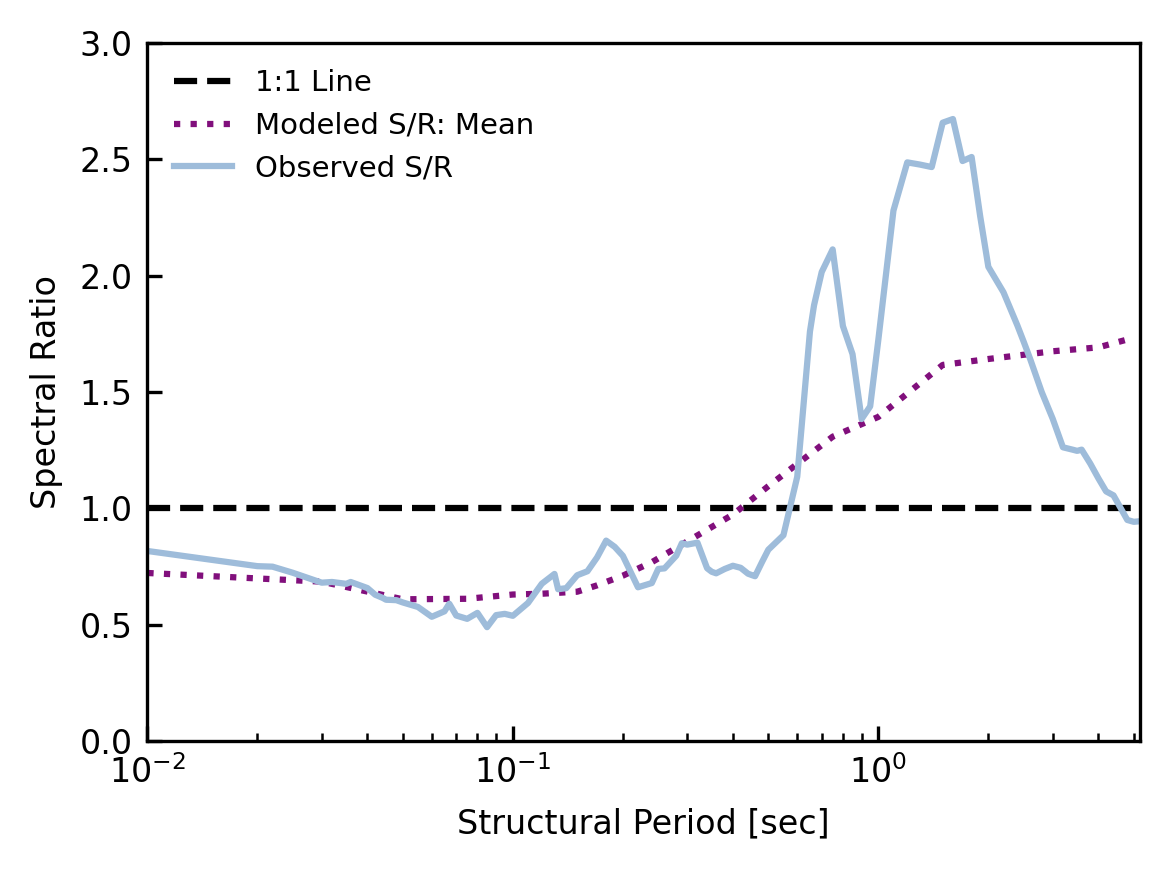

In [24]:
fig, ax = subplots(figsize=(4,3), tight_layout=True, dpi=300)
ax.hlines(1, xmin = 0.01, xmax = 5.2, color = "black", label = "1:1 Line", linestyle = "--")
ax.semilogx(np.asarray(as97_const["period"], "float"), SR_model, color = "#810f7c", label="Modeled S/R: Mean", linestyle =":")
ax.semilogx(np.asarray(loma_soil_spectra.index.values, "float"), SR_obs, color = "#9ebcda", label="Observed S/R")

plt.legend(loc="best", fontsize=7, frameon=False)

ax.set_xlabel("Structural Period [sec]", fontsize = 8)
ax.set_xbound(0.01, 5.2)
ax.set_ylabel("Spectral Ratio", fontsize =8)
ax.set_ybound(0, 3)
ax.tick_params(which="both", direction = "in", labelsize = 8)

(d) Suppose you had a 1-story building and a 10-story building that had fundamental periods (in seconds) that were approximately equal to their number of stories divided by 10. For this earthquake, would the 1-story building have experienced greater loading if it was located at Gilroy 1 or at Gilroy 2? How about for the 10-story building?

In [25]:
# answered in word doc

## Problem 2

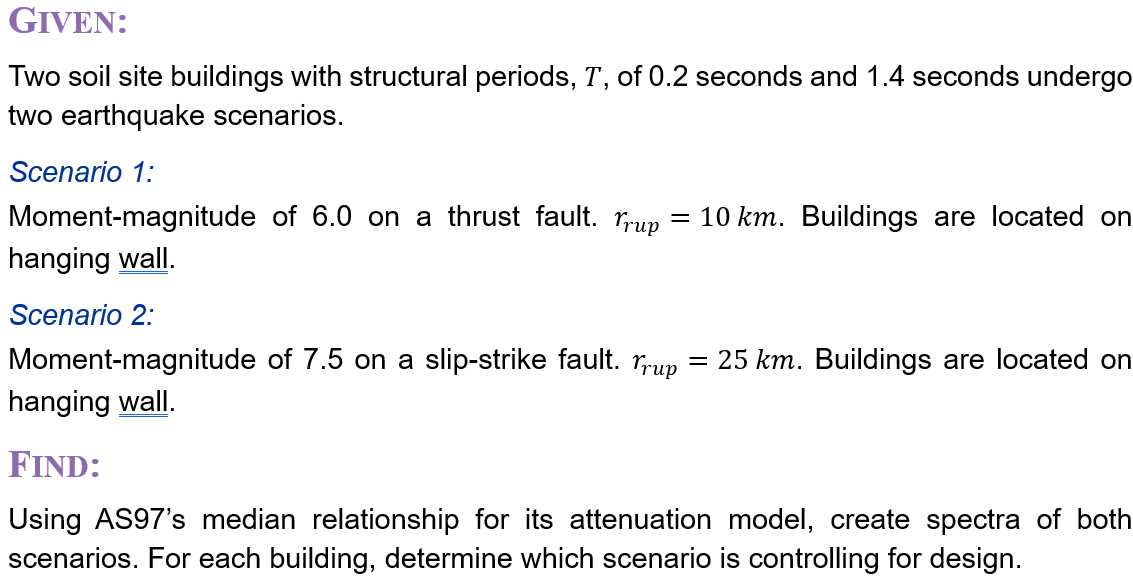

Ground motions should look like this:

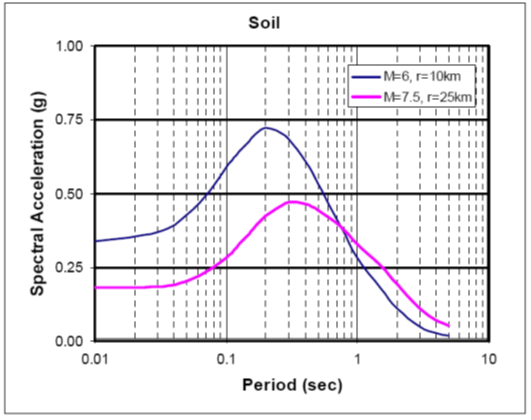


Recall: 

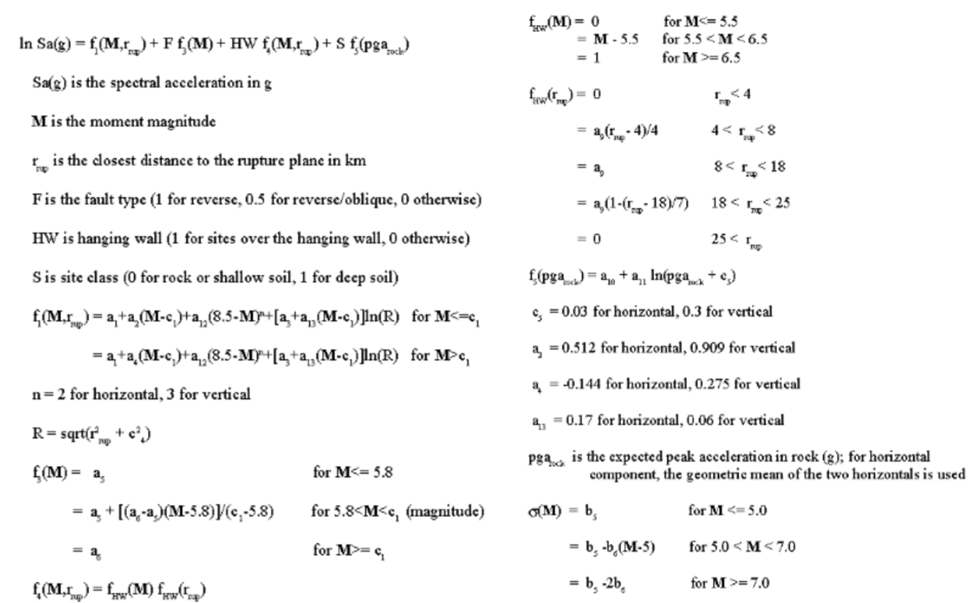

In [26]:
# collect dict of parameters of different scenarios
scen_1 = {"M":6, "mech": 1, "r_rup": 10, "HW": 1, "S": 1}
scen_2 = {"M":7.5, "mech": 0, "r_rup": 25, "HW": 1, "S": 1}
n=2 # consider horizontal motion
print(scen_1)
print(scen_2)
periods = np.asarray(as97_const["period"], "float") # periods to be considered
print(periods)

{'M': 6, 'mech': 1, 'r_rup': 10, 'HW': 1, 'S': 1}
{'M': 7.5, 'mech': 0, 'r_rup': 25, 'HW': 1, 'S': 1}
[0.01  0.03  0.05  0.075 0.1   0.12  0.15  0.17  0.2   0.24  0.3   0.4
 0.5   0.75  1.    1.5   2.    3.    4.    5.   ]


### AS97 Working Model

In [27]:
R_s1 = np.zeros(len(as97_const["period"])) # initialize R
for i in range(len(as97_const["period"])): # for each period
    R_s1[i] = (scen_1['r_rup']**2 + as97_const["c4"][i]**2)**0.5

# collect f1 values
f1_s1 = np.zeros(len(as97_const["period"])) # initialize f1
for i in range(len(as97_const["period"])): # for each period
    if scen_1['M'] <= as97_const["c1"][i]: # if M <= c1...
        f1_s1[i] = as97_const["a1"][i] + (as97_const["a2"][i] * (scen_1['M'] - as97_const["c1"][i])) + (as97_const["a12"][i]*(8.5 - scen_1['M'])**n) + \
            (as97_const["a3"][i] +(as97_const["a13"][i] * (scen_1['M']-as97_const["c1"][i])))*np.log(R_s1[i]) # collect f1 value
    else: # if M > c1...
        f1_s1[i] = as97_const["a1"][i] + (as97_const["a4"][i] * (scen_1['M'] - as97_const["c1"][i])) + (as97_const["a12"][i]*(8.5 - scen_1['M'])**n) + \
            (as97_const["a3"][i] +(as97_const["a13"][i] * (scen_1['M']-as97_const["c1"][i])))*np.log(R_s1[i]) # collect f1 value
        
# collect f3 values
f3_s1 = np.zeros(len(as97_const["period"])) # initialize f3
for i in range(len(as97_const["period"])): # for each period
    if scen_1["M"] <= 5.8: # if M <= 5.8...
        f3_s1[i] = as97_const["a5"][i] # collect f3 value
    elif 5.8 < scen_1["M"]  <= as97_const["c1"][i]: # if M > 5.8 and M <= 6.2...
        f3_s1[i] = as97_const["a5"][i] + (((as97_const["a6"][i] - as97_const["a5"][i])*(scen_1["M"]-5.8))/(as97_const["c1"][i]-5.8)) # collect f3 value
    else: # if M > 6.2...
        f3_s1[i] = as97_const["a6"][i] # collect f3 value

# in order to get f4, we need fHW_hw and fHW_r 
fHW_hw_s1 = np.zeros(len(as97_const["period"])) # initialize fHW_hw
for i in range(len(as97_const["period"])): # for each period
    if scen_1["M"] <= 5.5: # if if M <= 5.5
        fHW_hw_s1[i] = 0 # collect fHW_hw value
    elif 5.5 < scen_1["M"]  <= 6.5: # if 5.5 < M <= 6.5...
        fHW_hw_s1[i] = scen_1["M"] - 5.5 # collect fHW_hw value
    else: # if M > 6.5
        fHW_hw_s1[i] = 1 # collect fHW_hw value

fHW_r_s1 = np.zeros(len(as97_const["period"])) # initialize fHW_r
for i in range(len(as97_const["period"])): # for each period
    if scen_1["r_rup"] < 4: 
        fHW_r_s1[i] = 0 # collect fHW_r value
    elif 4 <= scen_1["r_rup"] < 8: 
        fHW_r_s1[i] = (as97_const["a9"][i] * (scen_1["r_rup"] - 4))/4 # collect fHW_r value
    elif 8 <= scen_1["r_rup"] < 18: 
        fHW_r_s1[i] = as97_const["a9"][i] # collect fHW_r value
    elif 18 <= scen_1["r_rup"] < 25: 
        fHW_r_s1[i] = as97_const["a9"][i] * (((1-(scen_1["r_rup"] - 18))/7))  # collect fHW_r value
    else:
        fHW_r_s1[i] = 0 # collect fHW_r value

# finally we can get f4...
f4_s1 = fHW_hw_s1 * fHW_r_s1

# collect f5 values. must ignore f5 first, then run again
f5_s1 = np.zeros(len(as97_const["period"])) # initialize f5, we will collect this later

# combine factors with flags to get ln(S_a) and by extension, S_a

lnSa_s1_median = np.zeros(len(as97_const["period"])) # initialize lnSa
for i in range(len(as97_const["period"])): # for each period
    if i == 0:
        print(f"R: {R_s1[i]}")
        print(f"f1: {f1_s1[i]}")
        print(f"f3: {scen_1['mech'] * f3_s1[i]}")
        print(f"f4: {scen_1['HW'] * f4_s1[i]}")
        scen_1["PGA_rock"] = np.exp(f1_s1[i] + scen_1["mech"] * f3_s1[i] + scen_1["HW"] * f4_s1[i])  # collect lnSa value
        print(f"PGA_rock: {scen_1['PGA_rock']}")
        f5_s1[i] = as97_const["a10"][i] + as97_const["a11"][i] * np.log(scen_1["PGA_rock"] + as97_const["c5"][i]) # collect f5 value
        lnSa_s1_median[i] = f1_s1[i] + scen_1["mech"] * f3_s1[i] + scen_1["HW"] * f4_s1[i] + scen_1["S"]*f5_s1[i]  # collect lnSa value
        print(f"ln(S_a [g]): {lnSa_s1_median[i]}")
    else:
        for i in range(len(as97_const["period"])): # for each period
            f5_s1[i] = as97_const["a10"][i] + as97_const["a11"][i] * np.log(scen_1["PGA_rock"] + as97_const["c5"][i]) # collect f5 value
            lnSa_s1_median[i] = f1_s1[i] + scen_1["mech"] * f3_s1[i] + scen_1["HW"] * f4_s1[i] + scen_1["S"]*f5_s1[i]  # collect lnSa value

print(f"Structural Periods [sec]: {np.asarray(as97_const['period'], 'float')}")
print(f"ln(S_a [g]): {lnSa_s1_median}") # median case of lnSa
Sa_s1_mean = np.exp(lnSa_s1_median)

print(f"S_a [g]: {Sa_s1_mean}") # mean case of Sa


R: 11.461239025515521
f1: -1.5232716081195476
f3: 0.4933333333333333
f4: 0.185
PGA_rock: 0.429583873548832
ln(S_a [g]): -1.0831284958097063
Structural Periods [sec]: [0.01  0.03  0.05  0.075 0.1   0.12  0.15  0.17  0.2   0.24  0.3   0.4
 0.5   0.75  1.    1.5   2.    3.    4.    5.   ]
ln(S_a [g]): [-1.0831285  -0.9967535  -0.85251893 -0.67005586 -0.52481007 -0.45844956
 -0.38911445 -0.35114269 -0.32240856 -0.33631562 -0.37997294 -0.49591653
 -0.62954104 -0.94998721 -1.26459107 -1.72986169 -2.20724955 -2.98724955
 -3.60071621 -4.04731621]
S_a [g]: [0.33853476 0.3690757  0.42633966 0.51167999 0.59166773 0.63226317
 0.6776567  0.70388331 0.72440217 0.71439759 0.68387991 0.60901247
 0.5328363  0.38674597 0.28235474 0.17730893 0.11000279 0.05042594
 0.02730416 0.0174692 ]


In [28]:
R_s2 = np.zeros(len(as97_const["period"])) # initialize R
for i in range(len(as97_const["period"])): # for each period
    R_s2[i] = (scen_2['r_rup']**2 + as97_const["c4"][i]**2)**0.5

# collect f1 values
f1_s2 = np.zeros(len(as97_const["period"])) # initialize f1
for i in range(len(as97_const["period"])): # for each period
    if scen_2['M'] <= as97_const["c1"][i]: # if M <= c1...
        f1_s2[i] = as97_const["a1"][i] + (as97_const["a2"][i] * (scen_2['M'] - as97_const["c1"][i])) + (as97_const["a12"][i]*(8.5 - scen_2['M'])**n) + \
            (as97_const["a3"][i] +(as97_const["a13"][i] * (scen_2['M']-as97_const["c1"][i])))*np.log(R_s2[i]) # collect f1 value
    else: # if M > c1...
        f1_s2[i] = as97_const["a1"][i] + (as97_const["a4"][i] * (scen_2['M'] - as97_const["c1"][i])) + (as97_const["a12"][i]*(8.5 - scen_2['M'])**n) + \
            (as97_const["a3"][i] +(as97_const["a13"][i] * (scen_2['M']-as97_const["c1"][i])))*np.log(R_s2[i]) # collect f1 value
        
# collect f3 values
f3_s2 = np.zeros(len(as97_const["period"])) # initialize f3
for i in range(len(as97_const["period"])): # for each period
    if scen_2["M"] <= 5.8: # if M <= 5.8...
        f3_s2[i] = as97_const["a5"][i] # collect f3 value
    elif 5.8 < scen_2["M"]  <= as97_const["c1"][i]: # if M > 5.8 and M <= 6.2...
        f3_s2[i] = as97_const["a5"][i] + (((as97_const["a6"][i] - as97_const["a5"][i])*(scen_2["M"]-5.8))/(as97_const["c1"][i]-5.8)) # collect f3 value
    else: # if M > 6.2...
        f3_s2[i] = as97_const["a6"][i] # collect f3 value

# in order to get f4, we need fHW_hw and fHW_r 
fHW_hw_s2 = np.zeros(len(as97_const["period"])) # initialize fHW_hw
for i in range(len(as97_const["period"])): # for each period
    if scen_2["M"] <= 5.5: # if if M <= 5.5
        fHW_hw_s2[i] = 0 # collect fHW_hw value
    elif 5.5 < scen_2["M"]  <= 6.5: # if 5.5 < M <= 6.5...
        fHW_hw_s2[i] = scen_2["M"] - 5.5 # collect fHW_hw value
    else: # if M > 6.5
        fHW_hw_s2[i] = 1 # collect fHW_hw value

fHW_r_s2 = np.zeros(len(as97_const["period"])) # initialize fHW_r
for i in range(len(as97_const["period"])): # for each period
    if scen_2["r_rup"] < 4: 
        fHW_r_s2[i] = 0 # collect fHW_r value
    elif 4 <= scen_2["r_rup"] < 8: 
        fHW_r_s2[i] = (as97_const["a9"][i] * (scen_2["r_rup"] - 4))/4 # collect fHW_r value
    elif 8 <= scen_2["r_rup"] < 18: 
        fHW_r_s2[i] = as97_const["a9"][i] # collect fHW_r value
    elif 18 <= scen_2["r_rup"] < 25: 
        fHW_r_s2[i] = as97_const["a9"][i] * (((1-(scen_2["r_rup"] - 18))/7))  # collect fHW_r value
    else:
        fHW_r_s2[i] = 0 # collect fHW_r value

# finally we can get f4...
f4_s2 = fHW_hw_s2 * fHW_r_s2

# collect f5 values. must ignore f5 first, then run again
f5_s2 = np.zeros(len(as97_const["period"])) # initialize f5, we will collect this later

# combine factors with flags to get ln(S_a) and by extension, S_a

lnSa_s2_median = np.zeros(len(as97_const["period"])) # initialize lnSa
for i in range(len(as97_const["period"])): # for each period
    if i == 0:
        print(f"R: {R_s2[i]}")
        print(f"f1: {f1_s2[i]}")
        print(f"f3: {f3_s2[i]}")
        print(f"f4: {f4_s2[i]}")
        scen_2["PGA_rock"] = np.exp(f1_s2[i] + scen_2["mech"] * f3_s2[i] + scen_2["HW"] * f4_s2[i])  # collect lnSa value
        print(f"PGA_rock: {scen_2['PGA_rock']}")
        f5_s2[i] = as97_const["a10"][i] + as97_const["a11"][i] * np.log(scen_2["PGA_rock"] + as97_const["c5"][i]) # collect f5 value
        lnSa_s2_median[i] = f1_s2[i] + scen_2["mech"] * f3_s2[i] + scen_2["HW"] * f4_s2[i] + scen_2["S"]*f5_s2[i]  # collect lnSa value
        print(f"ln(S_a [g]): {lnSa_s2_median[i]}")
    else:
        for i in range(len(as97_const["period"])): # for each period
            f5_s2[i] = as97_const["a10"][i] + as97_const["a11"][i] * np.log(scen_2["PGA_rock"] + as97_const["c5"][i]) # collect f5 value
            lnSa_s2_median[i] = f1_s2[i] + scen_2["mech"] * f3_s2[i] + scen_2["HW"] * f4_s2[i] + scen_2["S"]*f5_s2[i]  # collect lnSa value

print(f"Structural Periods [sec]: {np.asarray(as97_const['period'], 'float')}")
print(f"ln(S_a [g]): {lnSa_s2_median}") # median case of lnSa
Sa_s2_mean = np.exp(lnSa_s2_median)

print(f"S_a [g]: {Sa_s2_mean}") # mean case of Sa


R: 25.61952380509833
f1: -1.6255338116564289
f3: 0.26
f4: 0.0
PGA_rock: 0.1968065895071635
ln(S_a [g]): -1.7012925514005988
Structural Periods [sec]: [0.01  0.03  0.05  0.075 0.1   0.12  0.15  0.17  0.2   0.24  0.3   0.4
 0.5   0.75  1.    1.5   2.    3.    4.    5.   ]
ln(S_a [g]): [-1.70129255 -1.68999255 -1.59169395 -1.41108314 -1.25899892 -1.14466035
 -1.01255376 -0.93299917 -0.85433621 -0.79787783 -0.75514523 -0.76900771
 -0.81435243 -0.94553261 -1.11290986 -1.3670515  -1.6347229  -2.1873229
 -2.6403229  -2.9656229 ]
S_a [g]: [0.18244755 0.1845209  0.20358046 0.24387899 0.28393813 0.31833202
 0.36329004 0.39337215 0.42556558 0.45028353 0.46994236 0.46347274
 0.44292606 0.38847261 0.32860138 0.2548573  0.1950064  0.11221676
 0.07133823 0.05152836]


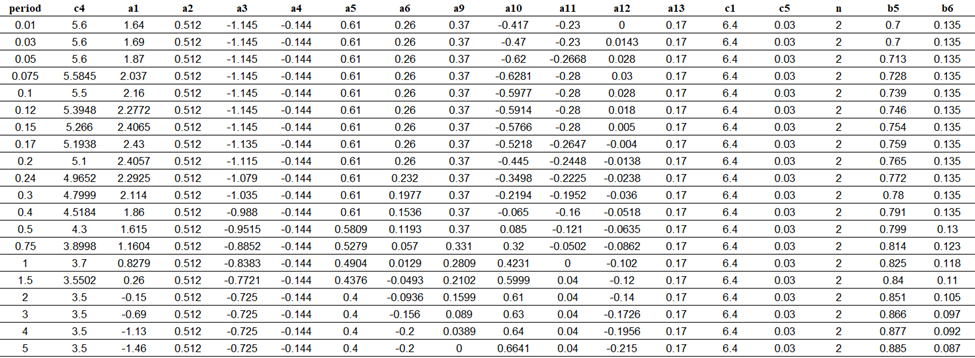

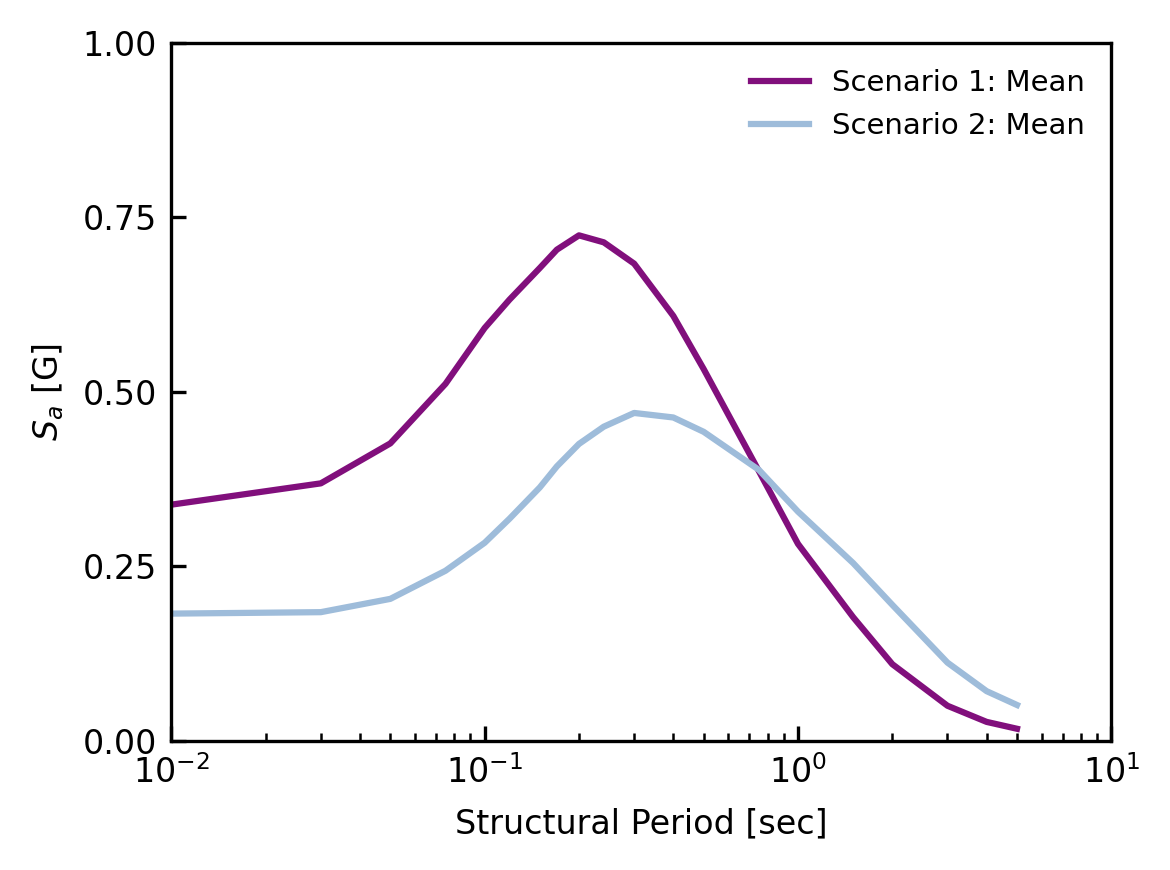

In [29]:
fig, ax = subplots(figsize=(4,3), tight_layout=True, dpi=300)
ax.semilogx(np.asarray(as97_const["period"], "float"), Sa_s1_mean, color = "#810f7c", label="Scenario 1: Mean", linestyle ="-")
ax.semilogx(np.asarray(as97_const["period"], "float"), Sa_s2_mean, color = "#9ebcda", label="Scenario 2: Mean", linestyle ="-")

plt.legend(loc="best", fontsize=7, frameon=False)

ax.set_xlabel("Structural Period [sec]", fontsize = 8)
ax.set_xbound(0.01, 10)
ax.set_ylabel("$S_a$ [G]", fontsize =8)
ax.set_ybound(0, 1)
ax.set_yticks([0,0.25,0.50,0.75,1])
ax.tick_params(which="both", direction = "in", labelsize = 8)

In [30]:
s1_factors = pd.DataFrame({"T": as97_const["period"], "f1": f1_s1, "f3": f3_s1, "f4": f4_s1, "f5": f5_s1, "lnSa": lnSa_s1_median, "Sa": Sa_s1_mean})
s2_factors = pd.DataFrame({"T": as97_const["period"], "f1": f1_s2, "f3": f3_s2, "f4": f4_s2, "f5": f5_s2, "lnSa": lnSa_s2_median, "Sa": Sa_s2_mean})

In [31]:
s1_table = gt.GT(np.round(s1_factors, 5)).cols_align('center')
s1_table

T,f1,f3,f4,f5,lnSa,Sa
0.01,-1.52327,0.49333,0.185,-0.23819,-1.08313,0.33853
0.03,-1.3839,0.49333,0.185,-0.29119,-0.99675,0.36908
0.05,-1.11827,0.49333,0.185,-0.41258,-0.85252,0.42634
0.075,-0.93797,0.49333,0.185,-0.41042,-0.67006,0.51168
0.1,-0.82312,0.49333,0.185,-0.38002,-0.52481,0.59167
0.12,-0.76306,0.49333,0.185,-0.37372,-0.45845,0.63226
0.15,-0.70853,0.49333,0.185,-0.35892,-0.38911,0.67766
0.17,-0.71346,0.49333,0.185,-0.31601,-0.35114,0.70388
0.2,-0.74606,0.49333,0.185,-0.25468,-0.32241,0.7244
0.24,-0.82849,0.484,0.185,-0.17682,-0.33632,0.7144


In [32]:
s2_table = gt.GT(np.round(s2_factors, 5)).cols_align('center')
s2_table

T,f1,f3,f4,f5,lnSa,Sa
0.01,-1.62553,0.26,0.0,-0.07576,-1.70129,0.18245
0.03,-1.56123,0.26,0.0,-0.12876,-1.68999,0.18452
0.05,-1.36753,0.26,0.0,-0.22416,-1.59169,0.20358
0.075,-1.19841,0.26,0.0,-0.21268,-1.41108,0.24388
0.1,-1.07672,0.26,0.0,-0.18228,-1.259,0.28394
0.12,-0.96868,0.26,0.0,-0.17598,-1.14466,0.31833
0.15,-0.85138,0.26,0.0,-0.16118,-1.01255,0.36329
0.17,-0.80392,0.26,0.0,-0.12908,-0.933,0.39337
0.2,-0.77254,0.26,0.0,-0.0818,-0.85434,0.42557
0.24,-0.77819,0.232,0.0,-0.01969,-0.79788,0.45028


## Problem 3

In [37]:
# collect spectra from Excel. may need to re-run since Vs30 is given, but Excel appears to take Vs as input
bchydro = pd.read_excel("BC-Hydro2016.xlsx", sheet_name="Results", header=0)
bc_Table = gt.GT(np.round(bchydro, 5)).cols_align('center')
bc_Table

period,760_med,760_plus,760_minus,560_med,560_plus,560_minus,270_med,270_plus,270_minus
0.01,0.15122,0.31694,0.07215,0.16523,0.34631,0.07883,0.19055,0.39939,0.09092
0.02,0.15122,0.31694,0.07215,0.16523,0.34631,0.07883,0.19055,0.39939,0.09092
0.05,0.1649,0.34562,0.07868,0.17103,0.35847,0.0816,0.17015,0.35663,0.08118
0.075,0.21694,0.45469,0.1035,0.22021,0.46154,0.10506,0.2058,0.43134,0.09819
0.1,0.27097,0.56794,0.12928,0.2785,0.58373,0.13288,0.26647,0.55851,0.12714
0.15,0.3097,0.6491,0.14776,0.32748,0.68637,0.15624,0.33392,0.69987,0.15932
0.2,0.30201,0.63299,0.14409,0.33207,0.696,0.15844,0.37,0.77549,0.17653
0.25,0.27558,0.57759,0.13148,0.31674,0.66387,0.15112,0.37247,0.78068,0.17771
0.3,0.26468,0.55475,0.12628,0.31706,0.66454,0.15127,0.39536,0.82864,0.18863
0.4,0.2506,0.52524,0.11957,0.31111,0.65207,0.14844,0.4321,0.90566,0.20616


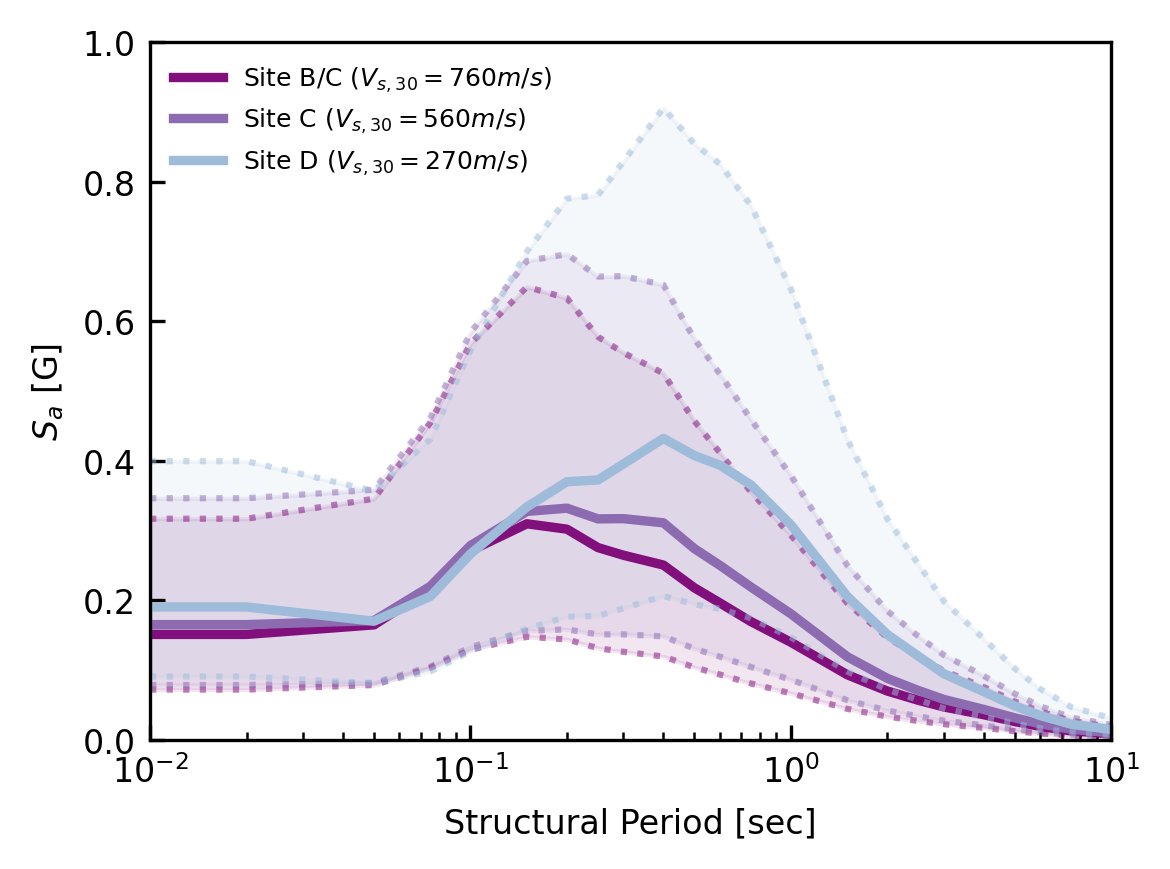

In [38]:
fig, ax = subplots(figsize=(4,3), tight_layout=True, dpi=300)
# plot site class B/C, which is 760 m/s
ax.semilogx(bchydro['period'], bchydro['760_med'], color = "#810f7c", label="Site B/C ($V_{s,30} = 760 m/s$)", linestyle ="-", linewidth =2.25)
ax.semilogx(bchydro['period'], bchydro['760_plus'], color = "#810f7c", linestyle = ":", alpha = 0.5)
ax.semilogx(bchydro['period'], bchydro['760_minus'], color = "#810f7c", linestyle = ":", alpha = 0.5)
ax.fill_between(bchydro['period'], bchydro['760_minus'], bchydro['760_plus'], color = "#810f7c", alpha = 0.1)

# plot site class C, which is 560 m/s
ax.semilogx(bchydro['period'], bchydro['560_med'], color = "#8c6bb1", label="Site C ($V_{s,30} = 560 m/s$)", linestyle ="-",   linewidth =2.25)
ax.semilogx(bchydro['period'], bchydro['560_plus'], color = "#8c6bb1", linestyle = ":", alpha = 0.5)
ax.semilogx(bchydro['period'], bchydro['560_minus'], color = "#8c6bb1", linestyle = ":", alpha = 0.5)
ax.fill_between(bchydro['period'], bchydro['560_minus'], bchydro['560_plus'], color = "#8c6bb1", alpha = 0.1)

# plot site class D, which is 270 m/s
ax.semilogx(bchydro['period'], bchydro['270_med'], color = "#9ebcda", label="Site D ($V_{s,30} = 270 m/s$)", linestyle ="-",   linewidth = 2.25)
ax.semilogx(bchydro['period'], bchydro['270_plus'], color = "#9ebcda", linestyle = ":", alpha = 0.5)
ax.semilogx(bchydro['period'], bchydro['270_minus'], color = "#9ebcda", linestyle = ":", alpha = 0.5)
ax.fill_between(bchydro['period'], bchydro['270_minus'], bchydro['270_plus'], color = "#9ebcda", alpha = 0.1)

ax.legend(loc="best", fontsize=6, frameon=False)
ax.set_xlabel("Structural Period [sec]", fontsize = 8)
ax.set_xbound(0.01, 10)
ax.set_ylabel("$S_a$ [G]", fontsize = 8)
ax.set_ybound(0, 1)
# ax.set_title("Spectral Acceleration vs. Structural Period", fontsize = 10)
ax.tick_params(direction='in', axis='both', which="both", labelsize=8)

plt.show()

## Problem 4

In [34]:
# collect spectra from CSVs
siteBC_spectra = np.genfromtxt("760ARSCSZ_1-26-2026_171338.csv", delimiter=",", skip_header=5, skip_footer=5)
siteC_spectra = np.genfromtxt("560ARSCSZ_1-26-2026_171414.csv", delimiter=",", skip_header=5, skip_footer=5)
siteD_spectra = np.genfromtxt("270ARSCSZ_1-26-2026_171530.csv", delimiter=",", skip_header=5, skip_footer=5)

In [35]:
siteBC_spectra

array([[0.        , 0.12229107],
       [0.05      , 0.13820122],
       [0.1       , 0.21173269],
       [0.15      , 0.23796419],
       [0.2       , 0.23349765],
       [0.25      , 0.2247075 ],
       [0.3       , 0.21721881],
       [0.4       , 0.20056841],
       [0.5       , 0.18301888],
       [0.6       , 0.16418204],
       [0.7       , 0.15415652],
       [0.8       , 0.14666124],
       [1.        , 0.12873495],
       [1.5       , 0.09739234],
       [2.        , 0.07688519],
       [2.5       , 0.06365169],
       [3.        , 0.05299164]])

C:\Users\bahea\AppData\Local\Temp\ipykernel_5892\3498856538.py:11: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xbound(0.0, 3.2)


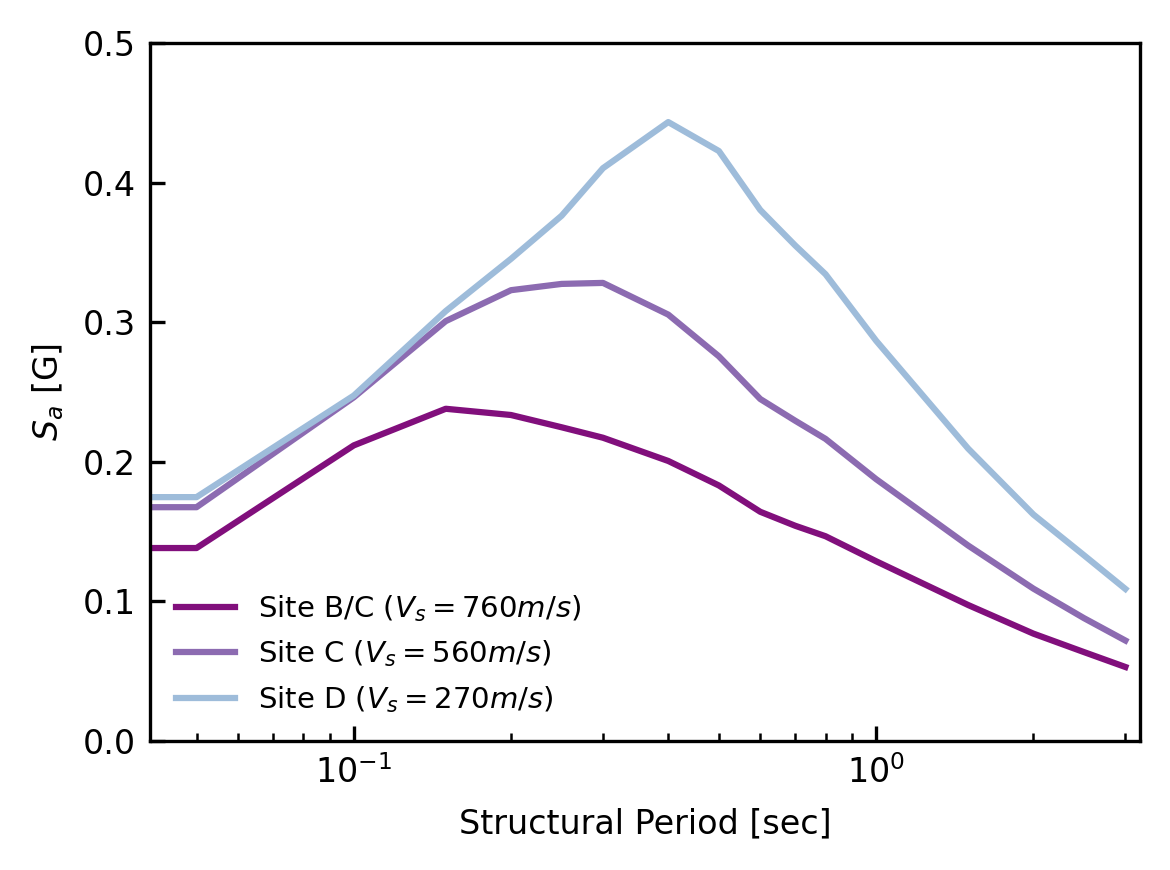

In [36]:
fig, ax = subplots(figsize=(4,3), tight_layout=True, dpi=300)
ax.semilogx(siteBC_spectra[:, 0], siteBC_spectra[:, 1], color = "#810f7c", label="Site B/C ($V_s = 760 m/s$)", linestyle ="-")
ax.semilogx(siteC_spectra[:, 0], siteC_spectra[:, 1], color = "#8c6bb1", label="Site C ($V_s = 560 m/s$)", linestyle = "-")
ax.semilogx(siteD_spectra[:, 0], siteD_spectra[:, 1], color = "#9ebcda", label="Site D ($V_s = 270 m/s$)", linestyle = "-")

plt.legend(loc="best", fontsize=7, frameon=False)

ax.set_xlabel("Structural Period [sec]", fontsize = 8)
ax.set_ylabel("$S_a$ [G]", fontsize =8)
ax.set_ybound(0, 0.5)
ax.set_xbound(0.0, 3.2)
ax.tick_params(which="both", direction = "in", labelsize = 8)

Problem 5

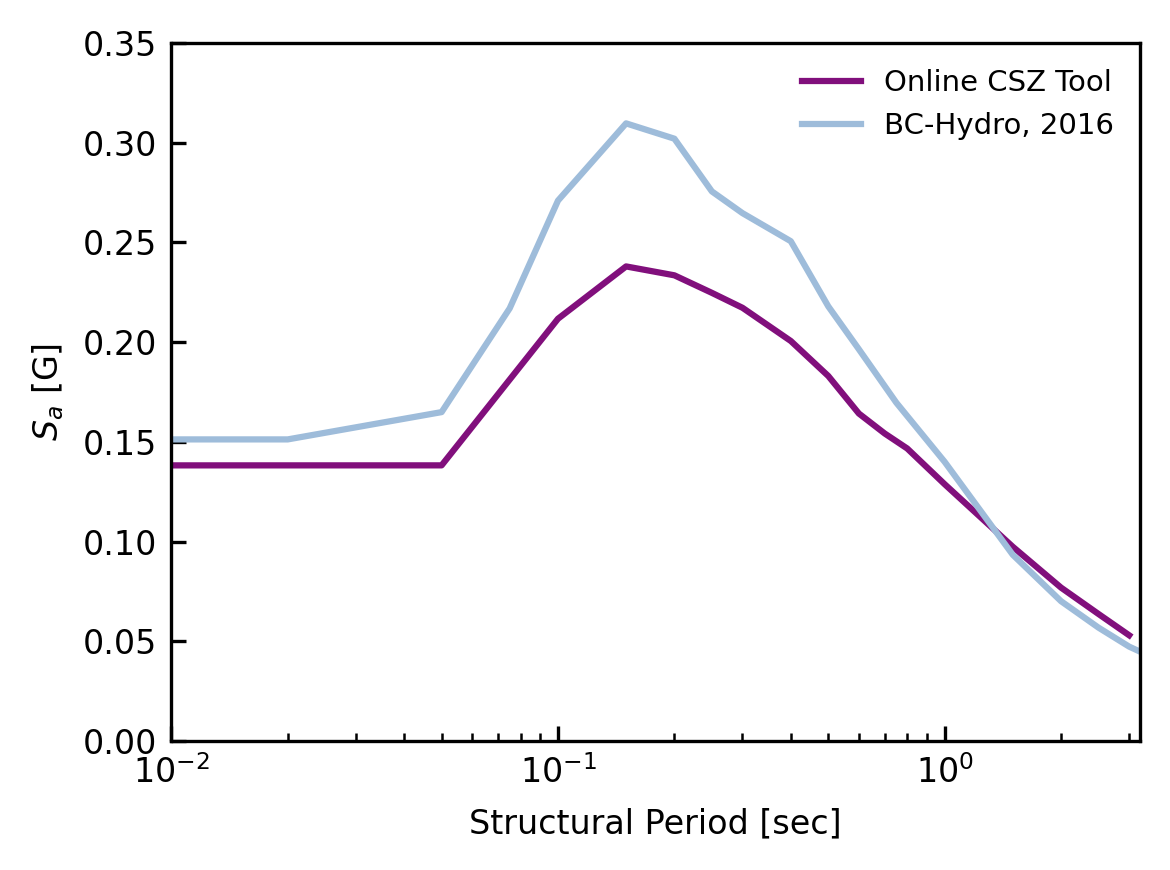

In [47]:
fig, ax = subplots(figsize=(4,3), tight_layout=True, dpi=300)
ax.semilogx(siteBC_spectra[:, 0], siteBC_spectra[:, 1], color = "#810f7c", label="Online CSZ Tool")
ax.semilogx(bchydro['period'], bchydro['760_med'], color = "#9ebcda", label="BC-Hydro, 2016")
plt.legend(loc="best", fontsize=7, frameon=False)

ax.set_xlabel("Structural Period [sec]", fontsize = 8)
ax.set_ylabel("$S_a$ [G]", fontsize =8)
ax.set_ybound(0, 0.35)
ax.set_xbound(0.01, 3.2)
ax.tick_params(which="both", direction = "in", labelsize = 8)